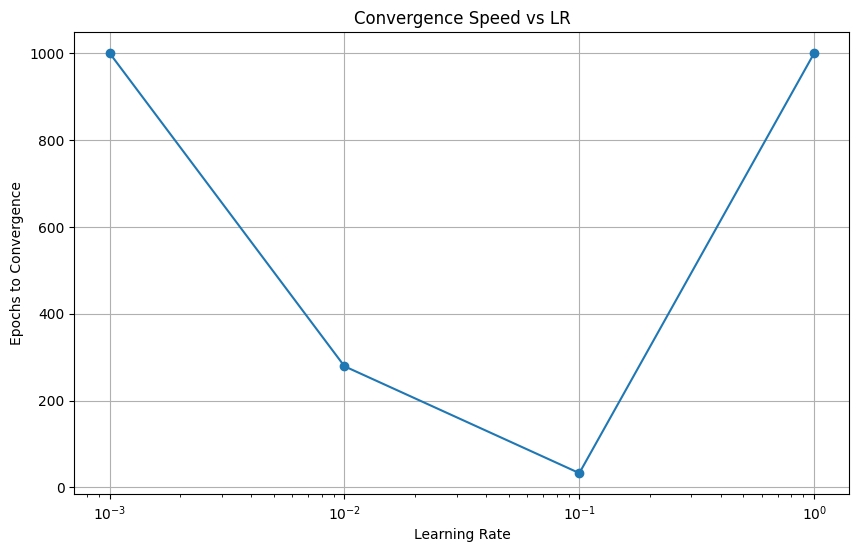

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Synthetic Data
torch.manual_seed(42)
X_tensor = torch.randn(1000, 1)
y_tensor = 2 * X_tensor + 3 + 0.1 * torch.randn(1000, 1)

# 2. Define Training Function
def train_until_convergence(learning_rate, max_epochs=1000, tolerance=1e-5):
    model = nn.Linear(1, 1)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    prev_loss = float('inf')
    
    for epoch in range(1, max_epochs + 1):
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        if not np.isfinite(current_loss):
            return max_epochs
            
        if abs(prev_loss - current_loss) < tolerance:
            return epoch
            
        prev_loss = current_loss
    return max_epochs

# 3. Perform Sweep
learning_rates = [0.001, 0.01, 0.1, 1.0]
epochs_to_converge = []

for lr in learning_rates:
    epochs = train_until_convergence(lr)
    epochs_to_converge.append(epochs)

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, epochs_to_converge, marker='o')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Epochs to Convergence')
plt.title('Convergence Speed vs LR')
plt.grid(True)
plt.show()

In [5]:
# pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

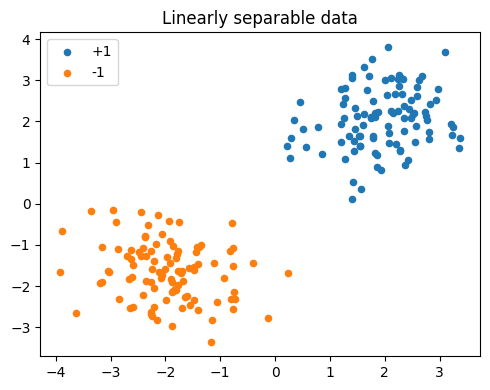

In [6]:
n_per_class = 100
 
# Class +1
mean1 = np.array([2, 2])
cov1  = np.array([[0.5, 0.1],[0.1, 0.5]])
X1 = np.random.multivariate_normal(mean1, cov1, size=n_per_class)
y1 =  np.ones(n_per_class, dtype=int)
 
# Class -1
mean2 = np.array([-2, -1.5])
cov2  = np.array([[0.6, -0.1],[-0.1, 0.6]])
X2 = np.random.multivariate_normal(mean2, cov2, size=n_per_class)
y2 = -np.ones(n_per_class, dtype=int)
 
X = np.vstack([X1, X2])      # shape (N, 2)
y = np.hstack([y1, y2])      # labels in {-1, +1}
 
# Shuffle
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]
 
# Quick plot
plt.figure(figsize=(5,4))
plt.scatter(X[y==1,0], X[y==1,1], s=20, label='+1')
plt.scatter(X[y==-1,0], X[y==-1,1], s=20, label='-1')
plt.legend(); plt.title('Linearly separable data'); plt.tight_layout(); plt.show()

In [7]:
class Perceptron:
    def __init__(self, lr=0.1, max_epochs=1000, shuffle=True):
        self.lr = lr
        self.max_epochs = max_epochs
        self.shuffle = shuffle
        self.w = None   # (d,)
        self.b = 0.0
 
    def predict_raw(self, X):
        return X @ self.w + self.b
 
    def predict(self, X):
        return np.where(self.predict_raw(X) >= 0, 1, -1)
 
    def fit(self, X, y):
        N, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        history = []
        for epoch in range(self.max_epochs):
            if self.shuffle:
                idx = np.random.permutation(N)
                X, y = X[idx], y[idx]
 
            errors = 0
            for xi, yi in zip(X, y):
                if yi * (self.w @ xi + self.b) <= 0:  # misclassified
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
 
            history.append(errors)
            if errors == 0:        # converged on separable data
                break
        self.history_ = history
        self.n_epochs_ = epoch + 1
        return self

Epochs: 2 | Train accuracy: 1.000 | Final errors: 0


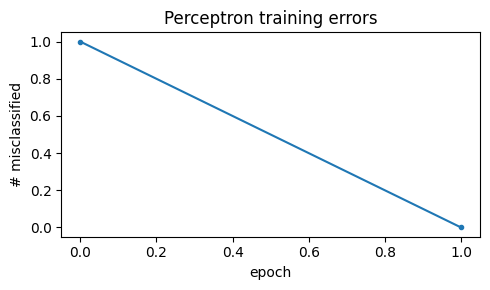

In [9]:
clf = Perceptron(lr=0.05, max_epochs=1000, shuffle=True).fit(X, y)
yhat = clf.predict(X)
acc = (yhat == y).mean()
print(f"Epochs: {clf.n_epochs_} | Train accuracy: {acc:.3f} | Final errors: {clf.history_[-1]}")
 
plt.figure(figsize=(5,3))
plt.plot(clf.history_, marker='o', ms=3)
plt.xlabel('epoch'); plt.ylabel('# misclassified'); plt.title('Perceptron training errors')
plt.tight_layout(); plt.show()

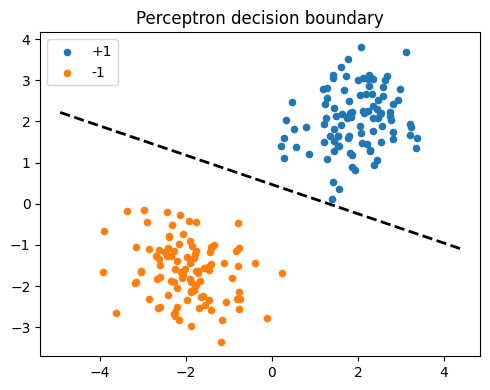

In [10]:
def plot_boundary(X, y, w, b):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    xs = np.linspace(x_min, x_max, 200)
    # w0*x + w1*y + b = 0  ->  y = -(w0*x + b)/w1
    if abs(w[1]) < 1e-9:
        # vertical line: x = -b/w0
        x_line = -b / w[0]
        ys = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
        plt.plot([x_line]*len(ys), ys, 'k--', lw=2)
    else:
        ys = -(w[0]*xs + b) / w[1]
        plt.plot(xs, ys, 'k--', lw=2)
 
plt.figure(figsize=(5,4))
plt.scatter(X[y==1,0], X[y==1,1], s=20, label='+1')
plt.scatter(X[y==-1,0], X[y==-1,1], s=20, label='-1')
plot_boundary(X, y, clf.w, clf.b)
plt.legend(); plt.title('Perceptron decision boundary'); plt.tight_layout(); plt.show()

In [11]:
class PocketPerceptron(Perceptron):
    def fit(self, X, y):
        N, d = X.shape
        self.w = np.zeros(d); self.b = 0.0
        best_w, best_b = self.w.copy(), self.b
        best_acc = 0.0
        history = []
        for epoch in range(self.max_epochs):
            if self.shuffle:
                idx = np.random.permutation(N)
                X, y = X[idx], y[idx]
            errors = 0
            for xi, yi in zip(X, y):
                if yi * (self.w @ xi + self.b) <= 0:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
            history.append(errors)
            acc = (np.where(X @ self.w + self.b >= 0, 1, -1) == y).mean()
            if acc > best_acc:
                best_acc = acc; best_w, best_b = self.w.copy(), self.b
        self.w, self.b = best_w, best_b
        self.history_ = history; self.n_epochs_ = self.max_epochs
        return self

Learning Rate   | Epochs
------------------------------
0.001           | 1000
0.01            | 279
0.1             | 33
1.0             | 1000


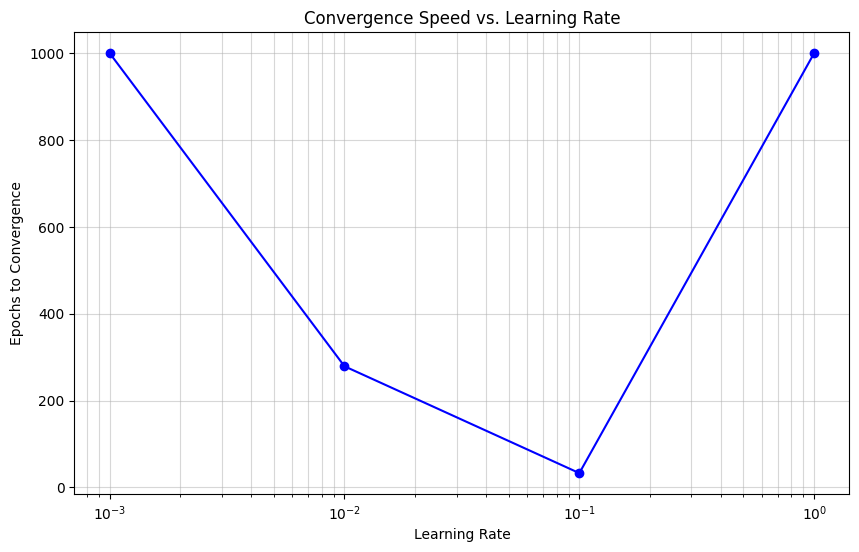

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

def train_until_convergence(X, y, learning_rate, max_epochs=1000, tolerance=1e-5):
    """
    Trains a simple linear model and returns the number of epochs to converge.
    """
    # Initialize a simple linear model (1 input, 1 output)
    model = nn.Linear(1, 1)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    prev_loss = float('inf')
    
    for epoch in range(1, max_epochs + 1):
        # Forward pass
        outputs = model(X)
        loss = criterion(outputs, y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        
        # Check for divergence (NaN or Infinity)
        if not np.isfinite(current_loss):
            return max_epochs
            
        # Check convergence criteria (change in loss is smaller than tolerance)
        if abs(prev_loss - current_loss) < tolerance:
            return epoch
            
        prev_loss = current_loss
        
    return max_epochs

def main():
    # 1. Setup Synthetic Data (as PyTorch Tensors)
    torch.manual_seed(42)
    X = torch.randn(1000, 1)
    # y = 2x + 3 + noise
    y = 2 * X + 3 + 0.1 * torch.randn(1000, 1)

    # 2. Perform the Sweep
    learning_rates = [0.001, 0.01, 0.1, 1.0]
    epochs_to_converge = []

    print(f"{'Learning Rate':<15} | {'Epochs'}")
    print("-" * 30)

    for lr in learning_rates:
        epochs = train_until_convergence(X, y, lr)
        epochs_to_converge.append(epochs)
        print(f"{lr:<15} | {epochs}")

    # 3. Plotting Results
    plt.figure(figsize=(10, 6))
    plt.plot(learning_rates, epochs_to_converge, marker='o', linestyle='-', color='b')

    # Formatting the plot
    plt.xscale('log')
    plt.xlabel('Learning Rate')
    plt.ylabel('Epochs to Convergence')
    plt.title('Convergence Speed vs. Learning Rate')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    
    # Show the plot
    plt.show()

if __name__ == "__main__":
    main()


Delta      | Epochs
-------------------------
2.0        | 2
1.5        | 2
1.0        | 2
0.8        | 2
0.5        | 10000
0.3        | 10000


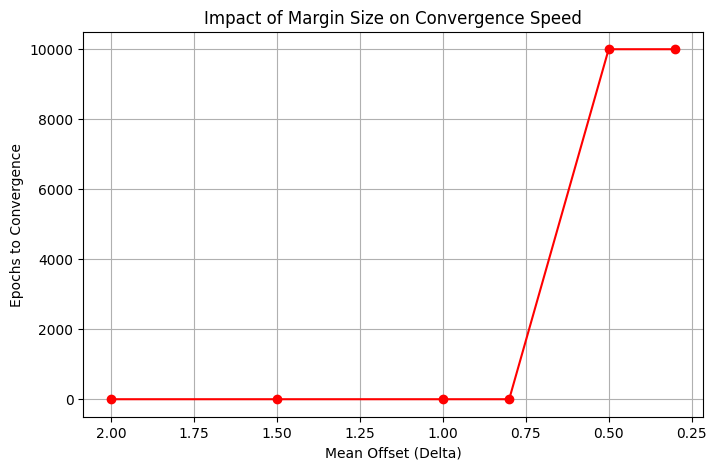

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Margin Stress Test
# We will shrink the distance (delta) between class means
deltas = [2.0, 1.5, 1.0, 0.8, 0.5, 0.3]
epochs_list = []

print(f"{'Delta':<10} | {'Epochs'}")
print("-" * 25)

for d in deltas:
    # Generate data with closer means
    # Using smaller covariance to maintain separability as long as possible
    cov_stress = np.array([[0.1, 0], [0, 0.1]])
    n_per_class = 100
    
    X1_s = np.random.multivariate_normal([d, d], cov_stress, size=n_per_class)
    y1_s = np.ones(n_per_class)
    
    X2_s = np.random.multivariate_normal([-d, -d], cov_stress, size=n_per_class)
    y2_s = -np.ones(n_per_class)
    
    X_s = np.vstack([X1_s, X2_s])
    y_s = np.hstack([y1_s, y2_s])
    
    # Shuffle
    perm = np.random.permutation(len(X_s))
    X_s, y_s = X_s[perm], y_s[perm]
    
    # Train
    # Increase max_epochs as small margins require more iterations
    clf_stress = Perceptron(lr=0.1, max_epochs=10000, shuffle=True)
    clf_stress.fit(X_s, y_s)
    
    epochs_list.append(clf_stress.n_epochs_)
    print(f"{d:<10} | {clf_stress.n_epochs_}")

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(deltas, epochs_list, marker='o', linestyle='-', color='r')
plt.xlabel('Mean Offset (Delta)')
plt.ylabel('Epochs to Convergence')
plt.title('Impact of Margin Size on Convergence Speed')
plt.grid(True)
plt.gca().invert_xaxis()  # Invert x-axis to show margin shrinking from left to right
plt.show()
